In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import joblib

In [2]:
df = pd.read_csv("city_day.csv")

In [3]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [5]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
print(df.shape)

(29531, 16)


In [9]:
print(df.columns)

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')


In [10]:
df = pd.read_csv("city_day.csv") # Reload df to ensure 'Date' column exists

# Date Feature Engineering
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df.drop('Date', axis=1, inplace=True)

# Drop rows where target variable 'AQI' is NaN, as we cannot predict missing values
df.dropna(subset=['AQI'], inplace=True)

# Fill remaining NaN values in numerical columns using the mean
# This should be done AFTER dropping rows with NaN in AQI to avoid using NaNs from those rows in mean calculation.
df.fillna(df.mean(numeric_only=True), inplace=True)

# Separate features (X) and target (y)
X = df.drop(['AQI'], axis=1)
y = df['AQI']

# Ensure X and y have no NaNs for target variable after all preprocessing
# This handles cases where NaNs might have been subtly reintroduced or not fully removed.
initial_rows = X.shape[0]
combined_data = pd.concat([X, y], axis=1)
combined_data.dropna(subset=['AQI'], inplace=True)
if combined_data.shape[0] < initial_rows:
    print(f"Dropped {initial_rows - combined_data.shape[0]} rows due to NaN in AQI after further checks.")
X = combined_data.drop('AQI', axis=1)
y = combined_data['AQI']

# One-hot encode 'City' and 'AQI_Bucket'
# AQI_Bucket NaNs are handled by the df.dropna(subset=['AQI']) step because AQI_Bucket is NaN when AQI is NaN.
X = pd.get_dummies(X, columns=['City', 'AQI_Bucket'], drop_first=True)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [13]:
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

Mean Absolute Error (MAE): 14.44
Mean Squared Error (MSE): 1001.12
R-squared (R2 Score): 0.95


In [15]:
print("MAE :", mean_absolute_error(y_test,pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test,pred)))
print("R2 Score :", r2_score(y_test,pred))

MAE : 14.440188128772633
RMSE : 31.64054959648466
R2 Score : 0.9453266767628161


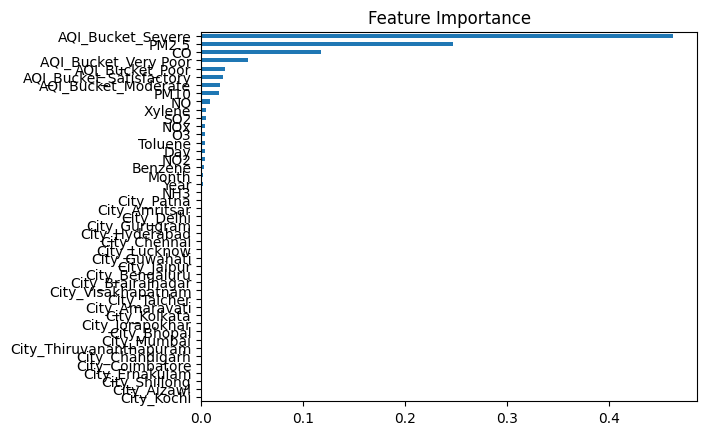

In [16]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [17]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [18]:
pred2 = xgb.predict(X_test)

print("MAE :", mean_absolute_error(y_test,pred2))
print("RMSE :", np.sqrt(mean_squared_error(y_test,pred2)))
print("R2 :", r2_score(y_test,pred2))

MAE : 15.107251317736129
RMSE : 31.344469850547924
R2 : 0.9463451119659205


In [19]:
joblib.dump(rf,"aqi_model.pkl")

['aqi_model.pkl']

In [20]:
joblib.dump(xgb,"aqi_model.pkl")

['aqi_model.pkl']

In [21]:
from google.colab import files

files.download("aqi_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import pandas as pd

sample = pd.DataFrame([{
    "PM2.5": 45.0,
    "PM10": 80.0,
    "NO": 18.0,
    "NO2": 30.0,
    "NOx": 40.0,
    "NH3": 20.0,
    "CO": 0.9,
    "SO2": 12.0,
    "O3": 25.0,
    "Benzene": 3.5,
    "Toluene": 8.0,
    "Xylene": 1.2
}])

In [23]:
import pandas as pd
import datetime

# Get the columns used during training (from X_train)
trained_columns = X_train.columns

# Create a new DataFrame for the sample with all trained columns, initialized to 0
sample_processed = pd.DataFrame(0, index=[0], columns=trained_columns)

# Populate the pollutant columns from the original sample
for col in sample.columns:
    if col in sample_processed.columns:
        sample_processed[col] = sample[col].iloc[0]

# Add representative values for Year, Month, Day.
# These were extracted from 'Date' during preprocessing.
# For a single sample prediction, you need to decide these. Using arbitrary representative values.
sample_processed['Year'] = 2020  # Example year
sample_processed['Month'] = 6    # Example month
sample_processed['Day'] = 15     # Example day

# Assuming no specific City or AQI_Bucket is provided for this generic sample,
# their one-hot encoded columns will remain 0, which is a valid input for prediction.

# Use the trained XGBoost model (xgb) for prediction
prediction = xgb.predict(sample_processed)

print("Predicted AQI:", round(prediction[0], 2))

Predicted AQI: 83.77


In [24]:
aqi = prediction[0]

if aqi <= 50:
    category = "Good"
elif aqi <= 100:
    category = "Satisfactory"
elif aqi <= 200:
    category = "Moderate"
elif aqi <= 300:
    category = "Poor"
elif aqi <= 400:
    category = "Very Poor"
else:
    category = "Severe"

print("AQI Category:", category)

AQI Category: Satisfactory


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [26]:
import joblib

joblib.dump(rf, "aqi_model.pkl")

['aqi_model.pkl']

In [27]:
from google.colab import files

files.download("aqi_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>